### Step1 : Import Libraries

In [8]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Step 2:Load Dataset

In [9]:
df = pd.read_csv("AI_Resume_Screening_Job_Market_Dataset_2026.csv")

df.head()

,candidate_id,job_title,industry,experience_years,education_level,skills_match_score,resume_score,location_type,salary_range_usd,ai_screening_result,interview_call,job_market_demand,year
0,C001,Data Scientist,IT,3,Master,82,85,Remote,70000-90000,Selected,Yes,High,2026
1,C002,Software Engineer,IT,1,Bachelor,65,70,Onsite,50000-65000,Rejected,No,High,2026
2,C003,ML Engineer,Finance,5,Master,90,92,Hybrid,90000-120000,Selected,Yes,High,2026
3,C004,Business Analyst,Healthcare,2,Bachelor,72,75,Onsite,55000-70000,Rejected,No,Medium,2026
4,C005,Data Analyst,E-commerce,4,Master,88,86,Remote,75000-95000,Selected,Yes,High,2026


### Step 3: Data Understanding

In [10]:
df.shape
df.isnull().sum()
df.info()
df.describe()
df['ai_screening_result'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   candidate_id         5 non-null      object
 1   job_title            5 non-null      object
 2   industry             5 non-null      object
 3   experience_years     5 non-null      int64 
 4   education_level      5 non-null      object
 5   skills_match_score   5 non-null      int64 
 6   resume_score         5 non-null      int64 
 7   location_type        5 non-null      object
 8   salary_range_usd     5 non-null      object
 9   ai_screening_result  5 non-null      object
 10  interview_call       5 non-null      object
 11  job_market_demand    5 non-null      object
 12  year                 5 non-null      int64 
dtypes: int64(4), object(9)
memory usage: 652.0+ bytes


ai_screening_result
Selected    3
Rejected    2
Name: count, dtype: int64

### Step 4: Text Cleaning Function

In [11]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['Cleaned_Resume'] = df['Resume'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\neha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


KeyError: 'Resume'

### step4 : Handle Categorical Data

In [12]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

### step 5 : Feature Selection 

In [13]:
X = df.drop('ai_screening_result', axis=1)
y = df['ai_screening_result']

### step 6 : Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### step 7: Model Training

In [15]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### step 8: Predictions

In [16]:
y_pred = model.predict(X_test)

### step 9: Evaluation

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



### step 10: Confusion Matrix

C:\Users\neha\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


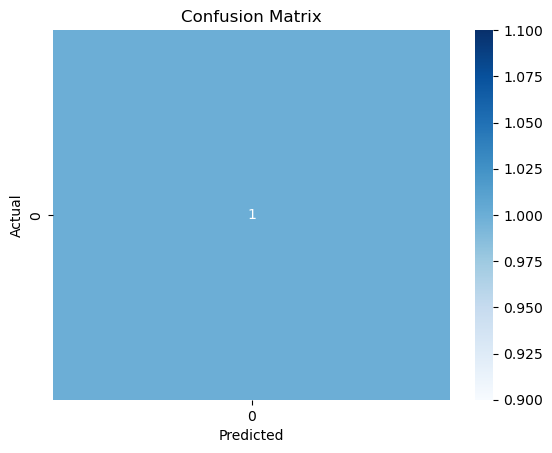

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### step 11: Feature importance 

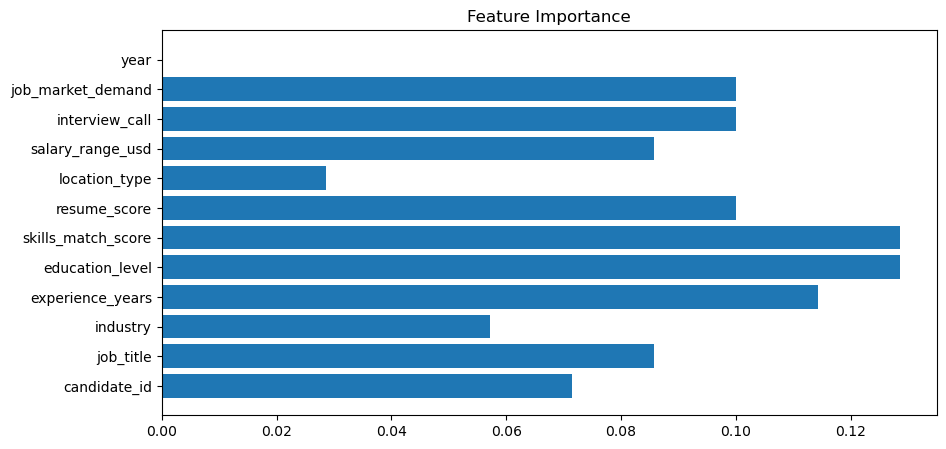

In [19]:
importances = model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(10,5))
plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.show()